Pregunta:
Teniendo los datos del primer parcial,segundo parcial y la Firma con el nuevo reglamento, estimar la nota final en la materia Mecanica de Solidos.

In [17]:
import pandas as pd
import numpy as np
import re
import glob

dl = glob.glob('/content/drive/MyDrive/IA-Dataset/nuevo/*.xlsx')
df_nuevo = pd.concat([pd.read_excel(file) for file in dl],ignore_index=True)

df = pd.read_excel('/content/drive/MyDrive/IA-Dataset/viejo/rendimiento_aдo_2024_ciclo_1_anon.xlsx')

df['Primer.Par']= (df['Primer.Par']/24)*100 #Normalizar 1er P
df['Segundo.Par']=(df['Segundo.Par']/36)*100 #Normalizar 2er P
df['AOT'] = (df['AOT']/10)*100 #Normalizar AOC
df['Firma'] = (df['Firma']/70)*100
## Extraccion de notas
df['Nota.Final']=df['parsed_value'] = (
    df['Nota.Final']
    .str.findall(r'-(\d+)')
    .apply(lambda x: max(map(int, x)) if isinstance(x, list) and len(x) > 0 else np.nan)
)
#Corregir la nota final tomando el mayor valor
df_nuevo['Nota.Final']=df_nuevo['parsed_value'] = (
    df_nuevo['Nota.Final']
    .str.findall(r'-(\d+)')
    .apply(lambda x: max(map(int, x)) if isinstance(x, list) and len(x) > 0 else np.nan)
)


In [27]:
# Mostrar información malla vieja completa
print("\n" + "=" * 70)
print("INFORMACIÓN DEL DATASET MALLA VIEJA")
print("=" * 70)
print(f"\nRegistros totales: {len(df):,}")
print(f"Estudiantes únicos: {df['ALUMNO_ID'].nunique():,}")
print(f"Asignaturas: {df['Asignatura'].nunique()}")
print(f"Carreras: {df['Cod.Car.Sec'].nunique()}")
print(f"\nDistribución de aprobados:")
print(df['Nota.Final'].value_counts())
print(f"Promedio de notas finales {(df['Nota.Final']).mean() }")
# Mostrar información malla nueva completa
print("\n" + "=" * 70)
print("INFORMACIÓN DEL DATASET MALLA NUEVA")
print("=" * 70)
print(f"\nRegistros totales: {len(df_nuevo):,}")
print(f"Estudiantes únicos: {df_nuevo['ALUMNO_ID'].nunique():,}")
print(f"Asignaturas: {df_nuevo['Asignatura'].nunique()}")
print(f"Carreras: {df_nuevo['Cod.Car.Sec'].nunique()}")
print(f"\nDistribución de notas:")
print(df_nuevo['Nota.Final'].value_counts())
print(f"Promedio de notas finales {(df_nuevo['Nota.Final']).mean()}")


INFORMACIÓN DEL DATASET MALLA VIEJA

Registros totales: 22,852
Estudiantes únicos: 4,313
Asignaturas: 225
Carreras: 27

Distribución de aprobados:
Nota.Final
5.0    6908
4.0    2489
2.0    2321
3.0    2300
1.0    1180
Name: count, dtype: int64
Promedio de notas finales 3.764837478615607

INFORMACIÓN DEL DATASET MALLA NUEVA

Registros totales: 64,295
Estudiantes únicos: 4,759
Asignaturas: 326
Carreras: 27

Distribución de notas:
Nota.Final
4.0    12586
2.0     9311
5.0     8992
3.0     8200
1.0     3631
Name: count, dtype: int64
Promedio de notas finales 3.3276451310861423


In [30]:
##Vars malla vieja
print(df.columns)
##Vars malla nueva
print("##################################")
print(df_nuevo.columns)
##Luego de percatarme de que Mecsol no se abrio en el periodo de la malla vieja
## procedi a solo utilizar los datos concatenados de la malla nueva.

Index(['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso',
       'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado',
       'Anho.Firma', 'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'AOT', 'Asis',
       'Requisito', 'Primer.Rec', 'Segundo.Rec', 'Nota.Final', 'Firma',
       'parsed_value'],
      dtype='object')
----------
Index(['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso',
       'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado',
       'Anho.Firma', 'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.',
       'Lab.', 'Proy.', 'Pond.PP', 'Pond.SP', 'Pond.TPLab', 'Pond.Lab',
       'Pond.Proy', 'Asis', 'Requisito', 'Firma', 'Primer.Rec', 'Segundo.Rec',
       'Nota.Final', 'FirmaCalculada', 'parsed_value'],
      dtype='object')


In [49]:
# =============================================================================
# 1.2 FILTRAR POR ASIGNATURA
# =============================================================================

print("\n" + "=" * 70)
print("FILTRANDO POR ASIGNATURA")
print("=" * 70)

# Buscar Mecanica de Solidos
if 'Asignatura' in df.columns:
    patrones = ['MECANICA DE SOLIDOS']
    mask1 = df['Asignatura'].str.upper().str.contains('|'.join(patrones), na=False)
    mask2 = df_nuevo['Asignatura'].str.upper().str.contains('|'.join(patrones), na=False)
    df_filtrado1 = df[mask1].copy()
    df_filtrado2 = df_nuevo[mask2].copy()
    print(f"✅ Registros de MecSol: {len(df_filtrado1)+len(df_filtrado2):,}")
else:
    df_filtrado1 = df.copy()
    df_filtrado2 = df_nuevo.copy()
    print(f"✅ Usando todos los registros: {len(df_filtrado1)+len(df_filtrado2):,}")

if len(df_filtrado1)==0 and len(df_filtrado2) == 0:
    print("⚠️ No se encontraron registros. Usando todos los datos.")
    df_filtrado1 = df.copy()
    df_filtrado2 = df_nuevo.copy()

# Mostrar distribución
if 'Nota.Final' in df_filtrado2.columns:
    print(f"\nDistribución de notas:")
    print(df_filtrado2['Nota.Final'].value_counts())
    print(f"Promedio de notas finales {(df_filtrado2['Nota.Final']).mean()}")




FILTRANDO POR ASIGNATURA
✅ Registros de MecSol: 234

Distribución de notas:
Nota.Final
2.0    48
3.0    34
4.0    34
5.0    16
1.0    16
Name: count, dtype: int64
Promedio de notas finales 2.9054054054054053


In [59]:
# Completa: Mostrar estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
print(df_filtrado2.describe())


print("\n=== Información del Dataset ===")
df_filtrado2.info()

# Completa: Verificar valores nulos
print("\n=== Valores Nulos ===")
df_filtrado2.isnull().sum()

=== Estadísticas Descriptivas ===
          Cod.Asign  Cod.Curso  Convocatoria         Anho  Semestre  \
count    234.000000      234.0         234.0   234.000000     234.0   
mean   15841.094017        5.0           1.0  2024.487179       2.0   
std     4133.889071        0.0           0.0     0.500907       0.0   
min    13608.000000        5.0           1.0  2024.000000       2.0   
25%    13711.000000        5.0           1.0  2024.000000       2.0   
50%    13711.000000        5.0           1.0  2024.000000       2.0   
75%    13711.000000        5.0           1.0  2025.000000       2.0   
max    23754.000000        5.0           1.0  2025.000000       2.0   

          Doc.Firma   Anho.Firma  Primer.Par  Segundo.Par  Tercer.Par  ...  \
count    234.000000   234.000000  234.000000   234.000000       234.0  ...   
mean   25206.487179  1349.512821   35.888889    46.384615         0.0  ...   
std    17871.052327   956.295325   22.253235    32.019534         0.0  ...   
min        0.0

,0
ALUMNO_ID,0
Cod.Asign,0
Asignatura,0
Cod.Car.Sec,0
Cod.Curso,0
Convocatoria,0
Anho,0
Semestre,0
Doc.Firma,0
Aprobado,0


In [58]:
df_filtrado2.head()

,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,...,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,FirmaCalculada,parsed_value
25317,FIUNA_ALUMNO_005475,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,0,0,1,1,72.0,70,0,5.0,NaN,5.0
25318,FIUNA_ALUMNO_008512,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,0,0,1,1,72.0,70,0,5.0,NaN,5.0
25319,FIUNA_ALUMNO_009719,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38604,S,...,0,0,1,1,60.0,0,0,2.0,NaN,2.0
25320,FIUNA_ALUMNO_009961,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38604,S,...,0,0,1,1,60.0,0,0,2.0,NaN,2.0
25321,FIUNA_ALUMNO_010008,13608,MECANICA DE SOLIDOS,MEC-PLS13,5,1,2025,2,38542,S,...,0,0,1,1,77.0,0,0,2.0,NaN,2.0


In [77]:
# =============================================================================
#  Seleccionando datos
# =============================================================================
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 70)
print("PREPARANDO DATOS PARA REDUCCIÓN")
print("=" * 70)

# Variables numéricas para reducción
variables_numericas = ['Primer.Par', 'Segundo.Par', 'Firma']
variables_existentes = [v for v in variables_numericas if v in df_filtrado2.columns]
print(f"\nVariables seleccionadas: {variables_existentes}")

# Crear DataFrame con variables numéricas
df_numericas = df_filtrado2[variables_existentes].copy()

# Convertir a numérico y limpiar
for col in variables_existentes:
    df_numericas[col] = pd.to_numeric(df_numericas[col], errors='coerce')

df_numericas = df_numericas.dropna()
print(f"\nRegistros después de limpiar: {len(df_numericas):,}")

# Variable objetivo (notas finales)
y=df_filtrado2['Nota.Final']

# Escalar datos
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df_numericas)
#print(f"\n✅ Datos escalados: {X_scaled.shape}")


PREPARANDO DATOS PARA REDUCCIÓN

Variables seleccionadas: ['Primer.Par', 'Segundo.Par', 'Firma']

Registros después de limpiar: 234

✅ Datos escalados: (234, 3)


In [173]:
if True in y.isnull() or True in df_numericas.isnull():
  print('YES')
else:
  print('NO, no null values')

NO, no null values


In [94]:
df_numericas.head()

,Primer.Par,Segundo.Par,Firma
25317,62,64,72.0
25318,62,64,72.0
25319,45,60,60.0
25320,45,60,60.0
25321,57,90,77.0


In [109]:
X=df_numericas.values
print(X[:,0])
#1p 2p firma

[62. 62. 45. 45. 57. 57.  0.  0. 24. 24.  0.  0. 27. 27.  0.  0. 40. 40.
  0.  0. 51. 51.  0.  0.  0.  0. 45. 45. 62. 62. 61. 61. 20. 20.  0.  0.
 40. 40. 32. 32. 25. 25. 60. 60. 38. 38. 64. 64. 50. 50. 40. 40. 77. 77.
 35. 35. 27. 27.  0.  0.  0.  0. 19. 19. 23. 23. 40. 40. 51. 51. 48. 48.
 48. 48. 48. 48. 40. 40. 15. 15. 64. 64. 30. 30. 15. 15. 62. 62. 40. 40.
  0.  0. 45. 45. 35. 35. 70. 70. 30. 30. 31. 31. 24. 24. 32. 32. 43. 43.
 42. 42. 55. 55. 66. 66. 35. 35.  0.  0. 60. 60. 55. 55.  0.  0. 50. 50.
 95. 95. 83. 83. 95. 95. 48. 48. 83. 83. 60. 60. 48. 48. 28. 28. 19. 19.
 37. 37. 38. 38. 43. 43. 17. 17. 61. 61. 35. 35. 33. 33. 23. 23. 66. 66.
 56. 56. 23. 23. 15. 15.  0.  0. 23. 23. 13. 13. 13. 13. 19. 19.  7.  7.
 16. 16. 29. 29. 55. 55.  7.  7. 30. 30. 36. 36. 45. 45. 62. 62. 46. 46.
 44. 44. 22. 22. 50. 50. 36. 36. 15. 15. 13. 13. 23. 23.  7.  7. 53. 53.
 41. 41. 75. 75. 40. 40. 21. 21. 13. 13. 49. 49. 13. 13. 49. 49. 30. 30.]


In [111]:
y_sal = y.values

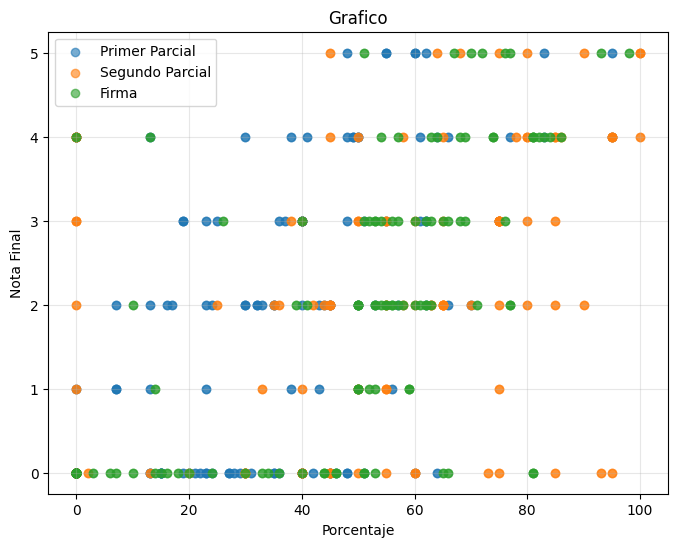

In [115]:
# Visualizar datos
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], y_sal, alpha=0.6, label='Primer Parcial')
plt.scatter(X[:,1], y, alpha=0.6, label='Segundo Parcial')
plt.scatter(X[:,2], y_sal, alpha=0.6, label='Firma')
plt.xlabel('Porcentaje')
plt.ylabel('Nota Final')
plt.title('Grafico')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [176]:
#Entrenamientos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_sal, test_size=0.2, random_state=42
)
##Regresion Lineal
modeloLin= LinearRegression()
modeloLin.fit(X_train, y_train)
##RandomForest, finetuning
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
modeloF = RandomForestRegressor(n_estimators=200, random_state=42)

grid_search = GridSearchCV(
    estimator=modeloF,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
#modeloF.fit(X_train, y_train)
grid_search.fit(X_train, y_train)
#Neural Networks
from tensorflow import keras
from tensorflow.keras import layers

modeloC = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

modeloC.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

modeloC.fit(
    X_train, y_train,
    epochs=500,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

#################################################
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)


Fitting 5 folds for each of 864 candidates, totalling 4320 fits


KeyboardInterrupt: 

In [174]:
# 7. Evaluar el modelo
#Regresion Lineal
print("Regresion Lineal")
y_predL = modeloLin.predict(X_test)

maeL=mean_absolute_error(y_test, y_predL)
rmseL=np.sqrt(mean_squared_error(y_test, y_predL))
R2L=r2_score(y_test, y_predL)
print("MAE:", maeL)
print("RMSE:", rmseL)
print("R2:", R2L)
#RandomForest
print("RandomForrest")
y_predF = modeloF.predict(X_test)

maeF=mean_absolute_error(y_test, y_predF)
rmseF=np.sqrt(mean_squared_error(y_test, y_predF))
R2F=r2_score(y_test, y_predF)
print("MAE:", maeF)
print("RMSE:", rmseF)
print("R2:", R2F)

#NeuronalNetwork
print("Neuronal Network")
y_predC = modeloC.predict(X_test)

maeC=mean_absolute_error(y_test, y_predL)
rmseC=np.sqrt(mean_squared_error(y_test, y_predL))
R2C=r2_score(y_test, y_predL)
print("MAE:", maeC)
print("RMSE:", rmseC)
print("R2:", R2C)

Regresion Lineal
MAE: 0.8969553054393252
RMSE: 1.2075156312777149
R2: 0.4762716023554374
RandomForrest
MAE: 0.5972222068711431
RMSE: 0.8816762583915946
R2: 0.7207849054688478
Neuronal Network
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
MAE: 0.8969553054393252
RMSE: 1.2075156312777149
R2: 0.4762716023554374


In [166]:
##Prueba sintetica
#El estudiante se encuentra antes de la fecha de los finales
#ya con firma y se pregunta que nota tendra si toma el examen final
# teniendo en cuenta su performance en los parciales.
#1P 2P Firma -----Nueva Malla
entrada=np.array([[70, 58, 78]])

print("Predictor Lineal",modeloLin.predict(entrada))
print("Predictor RandomForest",modeloF.predict(entrada))
print("Predictor Neuronal",modeloC.predict(entrada))
#

Predictor Lineal [3.44312496]
Predictor RandomForest [3.96333333]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predictor Neuronal [[3.8764799]]


In [175]:
data = {'MAE': [maeL,maeF,maeC], 'RMSE': [rmseL,rmseF,rmseC],'R2':[R2L,R2F,R2C]}
df_resultados = pd.DataFrame(data, index=['Regresion Lineal', 'Random Forest', 'Neuronal Network'])
print(df_resultados)
#

                       MAE      RMSE        R2
Regresion Lineal  0.896955  1.207516  0.476272
Random Forest     0.597222  0.881676  0.720785
Neuronal Network  0.896955  1.207516  0.476272


De acuerdo a la tabla de metricas, el random f